# TP4 - Improve the Metropolis-Hastings algorithm
**Computational Statistics (MVA 2025-2026)**  
**École Normale Supérieure Paris-Saclay**

**Student:** Yannaël Bossard  
**Email:** yannael.bossard@ens-paris-saclay.fr  
**Date:** 28 November 2025  
**Deadline:** 12 / 12 / 2025 - 23 h 59  
link of the Colab: https://colab.research.google.com/drive/1ZBo9IpTqJ4mWtr78EXqebkPyVakbnJS2?usp=sharing


In [1]:
# libraries
#%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.metrics import adjusted_rand_score
from scipy.stats import norm, expon
import sys, os
import time
import pandas as pd


In [2]:
seed = 13
np.random.seed(seed) # for reproduction

# Exercice 1: Adaptative Metropolis-Hastings within Gibbs sampler



## 1.A Question 1:

**summary:** It is called Random Scan Gibbs sampler because at each step, the algorithm randomly select which component/coordinate to update (probability 1/2 in the markov transition kernel).
The Metropolis Hastings sampler comes after component selection, inside the Gibbs sampler. Because the conditional distribution pi(x|y) or pi(y|x) cannot directly be saampled, MH does it.



## 1.A Question 2:

**summary:** First, We implemented the component kernel P1 and P2, sampling x and y based on Metropolis Hastings sampler. Then the function RandomScanGibbs sample the markov chain with kernel P, which as equal probability 1/2 to switch between P1 and P2.
We used log distribution from stability of computation.

In [3]:
def target_distri(x,y,a=1):
  '''
  Compute the target distribution Pi
  '''
  pi_distri = np.exp(-x**2/a**2-y**2-0.25*(x**2/a**2-y**2)**2)
  return pi_distri

def log_target_distri(z,a=1):
  '''
  Compute the logarithm target distribution Pi
  '''
  x, y = z
  pi_distri = (-x**2/a**2-y**2-0.25*(x**2/a**2-y**2)**2)
  return pi_distri


def sample_p1(z,sigma,a):
  '''
  Sample the distribution P1 (i-th component is x)
  '''
  (x,y) = z
  # Proposal x~N(0,sigma²)
  x_star = x + sigma*np.random.randn()

  # Calculate log-posterior of current z and next z*
  log_pi_k = log_target_distri((x,y),a)
  log_pi_star = log_target_distri((x_star,y),a)

  # log-Acceptance ratio: log(pi(z*)/pi(z_k))
  log_r = log_pi_star - log_pi_k
  #alpha = min(1, np.exp(log_r))
  alpha = np.exp(min(0, log_r)) # This appeared more stable

  if np.random.rand() < alpha:
    return (x_star,y),alpha
  else:
    return (x,y),alpha


def sample_p2(z,sigma,a):
  '''
  Sample the distribution P2 (i-th component is y)
  '''
  (x,y) = z
  # Proposal x~N(0,sigma²)
  y_star = y + sigma*np.random.randn()

  # Calculate log-posterior of current z and next z*
  log_pi_k = log_target_distri((x,y),a)
  log_pi_star = log_target_distri((x,y_star),a)

  # log-Acceptance ratio: log(pi(z*)/pi(z_k))
  log_r = log_pi_star - log_pi_k
  #alpha = min(1, np.exp(log_r))
  alpha = np.exp(min(0, log_r)) # This appeared more stable

  if np.random.rand() < alpha:
    return (x,y_star),alpha # Accepted
  else:
    return (x,y),alpha # Rejected


def RandomScanGibbs(n_iter, x0,sigmas=(3,3), a=10):
  '''
  Runs the Random Scan Gibbs sampler.
  '''
  sigma_x, sigma_y = sigmas
  samples = np.zeros((n_iter,2))
  samples[0] = x0
  x_i = x0
  acceptance_rate = np.zeros((n_iter,2))

  for i in range(1,n_iter):
    alpha_x,alpha_y = np.nan,np.nan
    if np.random.rand() < 0.5:
      # sample P1
      x_i,alpha_x = sample_p1(x_i,sigma=sigma_x,a=a)
    else:
      # sample P2
      x_i,alpha_y = sample_p2(x_i,sigma=sigma_y,a=a)

    samples[i] = x_i
    acceptance_rate[i] = [alpha_x,alpha_y]

  return samples, acceptance_rate


a = 10
n_iter = 5000
sigmas = (3,3)
x0 = np.random.rand(2)

samples, acceptance_rate = RandomScanGibbs(n_iter, x0, sigmas=sigmas,a=a)



## 1.A Question 3:

**summary:** We observed horizontale lines on the scatter plot. This can be interpreted as Y-coordinate getting stuck for several iterations (low acceptance-rate) while the X-coordinate continues to update successuflly. In fact, the high X-acceptance rate (≈85%) confirms the underexploration of the x-dimension. This is because a=10 make the target distribution highly anisotropic, and so using fixed isotropic σ is not adequat.


Therefore, σ = (3,3) seems suboptimal to explore this anisotropic space.
For instance, σ = (10,2) performs way better.




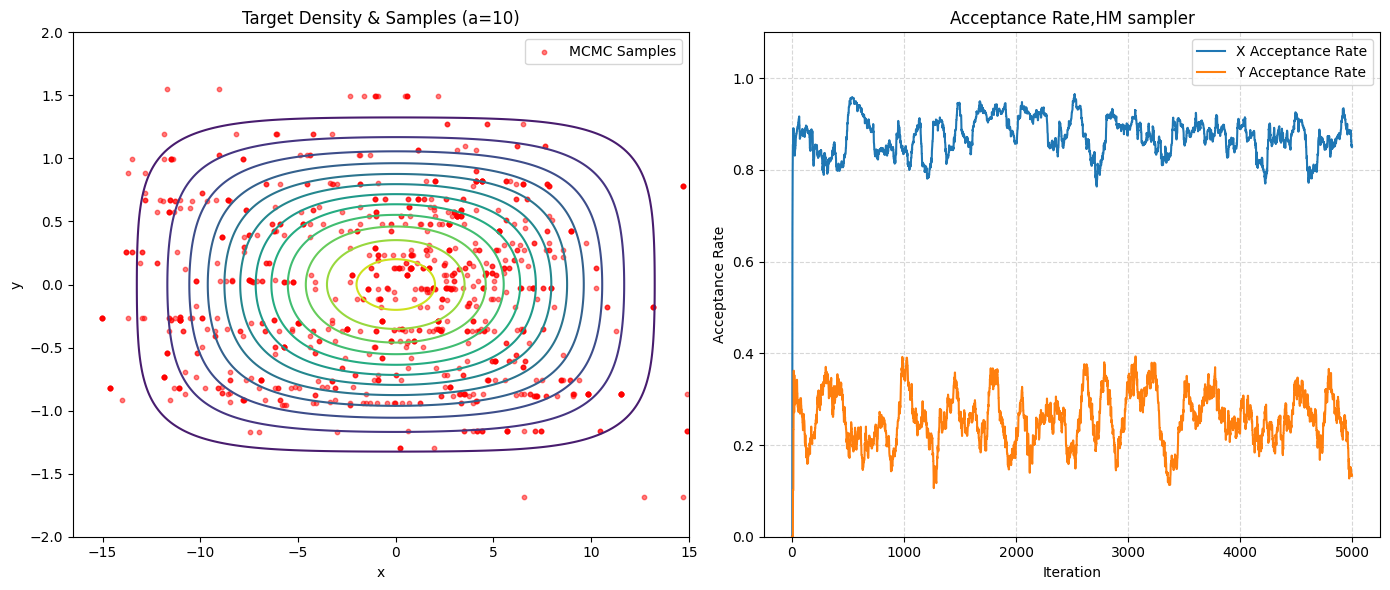

In [4]:
### Plotting
plt.figure(figsize=(14, 6))

# 1. Scatter Plot + Contour
plt.subplot(1, 2, 1)

# Create a grid for the contour plot
x_grid = np.linspace(-15, 15, 200)
y_grid = np.linspace(-2, 2, 200) # smaller because a=10 elongates x
X, Y = np.meshgrid(x_grid, y_grid)
Z = target_distri(X, Y, a=a)

# Contour
plt.contour(X, Y, Z, levels=15, cmap='viridis')
max_display = min(n_iter,1000)
plt.scatter(samples[:max_display, 0], samples[:max_display, 1], s=10, alpha=0.5, color='red', label='MCMC Samples')
plt.title(f'Target Density & Samples (a={a})')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

# 2. Acceptance Rate Plot
plt.subplot(1, 2, 2)

series_x = pd.Series(acceptance_rate[:, 0]) # handles NaN values
series_y = pd.Series(acceptance_rate[:, 1])
window = max(10,int(n_iter/50))
rate_x = series_x.rolling(window=window, min_periods=1).mean() # compute rate with rolling mean
rate_y = series_y.rolling(window=window, min_periods=1).mean()

plt.plot(rate_x, label='X Acceptance Rate')
plt.plot(rate_y, label='Y Acceptance Rate')

plt.title(f'Acceptance Rate,HM sampler')
plt.xlabel('Iteration')
plt.ylabel('Acceptance Rate')
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 1.A Question 4:

**summary:** We concluded in Question3 that isotropic σ is suboptimal to explore anisotropic space, and that for instance, σ = (10,2) performs a lot better.
Hence, improving the sampler would require to tune the proposal distirbution to match the geometry/distirbution of the target density π.

We could use manual tuning, but sees it subjective and time-consuming. Or we could use automatic tuning like Adaptative MCMC.


#
## 1.B Question 1:

**summary:** It seems that the adaptive algorithm successfully learns the geometry of the target distribution. As we guesses in previous questions, we observed that sigma_x increases significantly (as x spans a large range) while sigma_y remains small, close to initial conditions, and so X-acceptance rate takes more iteration to converge to optimal acceptance rate than y.

As expected, depending on initial condition, we observed that the autocorrelation for adaptative version remains more or less similar, as it's always targeting the target optimal acceptance rate, whereas the autocorrelation non-adaptative version can fluctuate a lot. These auto-correlation plots confirm that the adaptive sampler produces less correlated samples (better mixing), faster (no need of thand-tuning).

In [5]:

def delta_updator(j):
  '''
  Compute the updating step to move toward acceptance-rate 0.234
  '''
  delta_j = min(0.05,j**(-0.5))
  return delta_j

def li_2sigma(l_i):
  '''
  ℓi := log(σi) => σi = exp(ℓi)
  '''
  sigma = np.exp(l_i)
  return sigma


def sample_xi_given_xibar(target_distri,x_curr,dim_i,sigmas,a):
  '''
  Sample the distribution πi(xi | x−i) ∝ π(x)
  '''

  # Proposal x~N(0,sigma²)
  x_star = x_curr.copy()
  x_star[dim_i] += sigmas[dim_i]*np.random.randn()


  # Calculate log-posterior of current z and next z*
  log_pi_k = target_distri(x_curr,a)
  log_pi_star = target_distri(x_star,a)

  # log-Acceptance ratio: log(pi(z*)/pi(z_k))
  log_r = log_pi_star - log_pi_k
  #alpha = min(1, np.exp(log_r))
  alpha = np.exp(min(0, log_r)) # This appeared more stable

  if np.random.rand() < alpha:
    return x_star,alpha # Accepted
  else:
    return x_curr,alpha # Rejected

def AdaptativeMetropolisHastings(target_distri,n_iter, x0,sigmas=(3,3), a=10, batch_size=50, adaptation=True):
  '''
  Adaptive Metropolis-Hastings within Gibbs sampler with a fixed-order scan

  adaptation: Boolean -> set true to activate Adaptative Metropolis-Hastings within Gibbs sample, False to deativate the adaptative part
  '''

  d = len(x0)
  samples = np.zeros((n_iter, d))
  x_curr = x0.copy()
  samples[0] = x_curr

  if not adaptation:
    sigmas = sigmas
  else:
    ls = np.zeros(d)
    sigmas = li_2sigma(ls)

  acceptance_rate_batch = np.zeros((batch_size,d))
  acceptance_rate = np.zeros((n_iter,d))

  j_th_batch = 0
  history_sigmas = np.zeros((n_iter,d))
  for i in range(1,n_iter):

    if i%batch_size == batch_size-1 and adaptation:
      j_th_batch += 1

    for dim_i in range(d):

      if i%batch_size == batch_size-1 and adaptation: # After the j-th (j ∈ N∗) batch of 50 iterations, each variable ℓi is updated
        delta_j = delta_updator(j_th_batch)
        ls[dim_i] += delta_j*np.sign((np.nanmean(acceptance_rate_batch[:,dim_i])-0.234))
        sigmas[dim_i] = li_2sigma(ls[dim_i])

      x_curr, alpha = sample_xi_given_xibar(target_distri,x_curr,dim_i,sigmas=sigmas,a=a)

      samples[i] = x_curr
      acceptance_rate[i,dim_i] = alpha
      acceptance_rate_batch[i%batch_size,dim_i] = alpha
      history_sigmas[i,dim_i] = sigmas[dim_i]

  return samples, acceptance_rate, history_sigmas


a = 10
n_iter = 10000
x0 = np.random.rand(2)

samples_adapted, acceptance_rate_adapted, history_sigmas_adapted = AdaptativeMetropolisHastings(log_target_distri,n_iter, x0, sigmas=sigmas,a=a, adaptation=True)
samples_nonadapted, acceptance_rate_nonadapted, history_sigmas_nonadapted = AdaptativeMetropolisHastings(log_target_distri,n_iter, x0, sigmas=sigmas,a=a, adaptation=False)

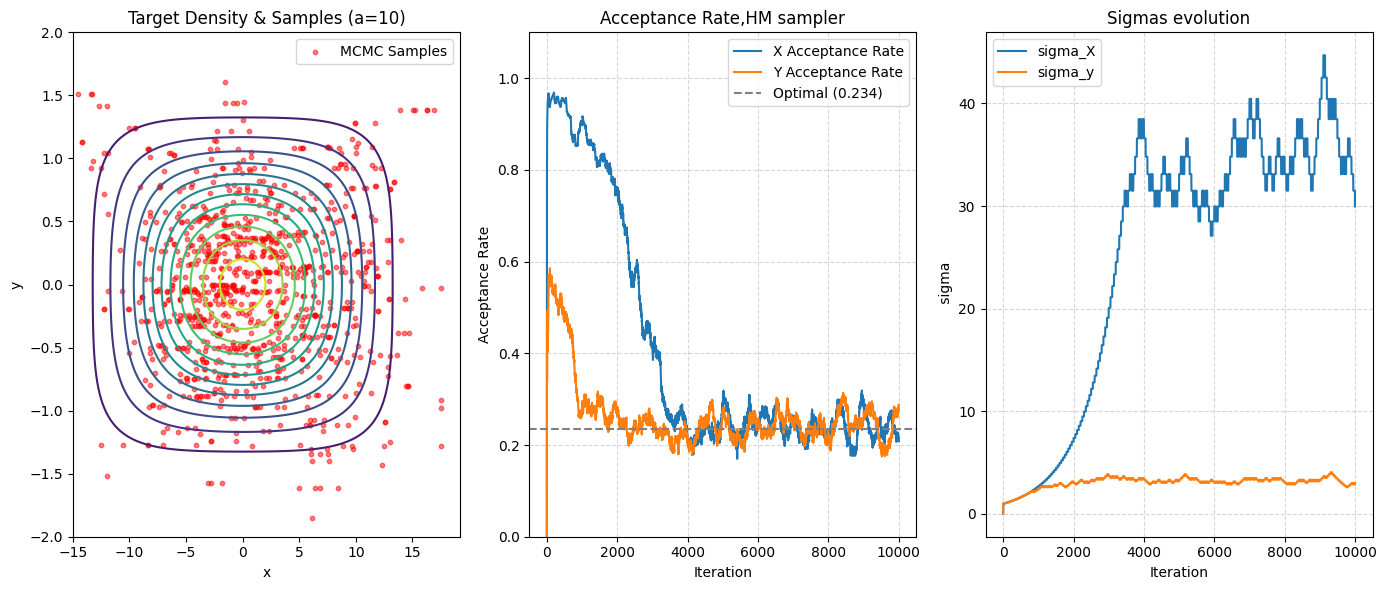

In [6]:
### Plotting
plt.figure(figsize=(14, 6))

# 1. Scatter Plot + Contour
plt.subplot(1, 3, 1)

# Create a grid for the contour plot
x_grid = np.linspace(-15, 15, 200)
y_grid = np.linspace(-2, 2, 200) # smaller because a=10 elongates x
X, Y = np.meshgrid(x_grid, y_grid)
Z = target_distri(X, Y, a=a)

# Contour
plt.contour(X, Y, Z, levels=15, cmap='viridis')
max_display = min(n_iter,1000)
plt.scatter(samples_adapted[:max_display, 0], samples_adapted[:max_display, 1], s=10, alpha=0.5, color='red', label='MCMC Samples')
plt.title(f'Target Density & Samples (a={a})')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

# 2. Acceptance Rate Plot
plt.subplot(1, 3, 2)

series_x = pd.Series(acceptance_rate_adapted[:, 0]) # handles NaN values
series_y = pd.Series(acceptance_rate_adapted[:, 1])
window = max(10,int(n_iter/50))
rate_x = series_x.rolling(window=window, min_periods=1).mean() # compute rate with rolling mean
rate_y = series_y.rolling(window=window, min_periods=1).mean()

plt.plot(rate_x, label='X Acceptance Rate')
plt.plot(rate_y, label='Y Acceptance Rate')

plt.title(f'Acceptance Rate,HM sampler')
plt.xlabel('Iteration')
plt.ylabel('Acceptance Rate')
plt.ylim(0, 1.1)
plt.axhline(0.234, color='gray', linestyle='--', label='Optimal (0.234)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)


# 3. Sigmas evolution
plt.subplot(1, 3, 3)

plt.plot(history_sigmas_adapted[:,0], label='sigma_X')
plt.plot(history_sigmas_adapted[:,1], label='sigma_y')

plt.title(f'Sigmas evolution')
plt.xlabel('Iteration')
plt.ylabel(' sigma')
#plt.axhline(0.234, color='gray', linestyle='--', label='Optimal (0.234)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

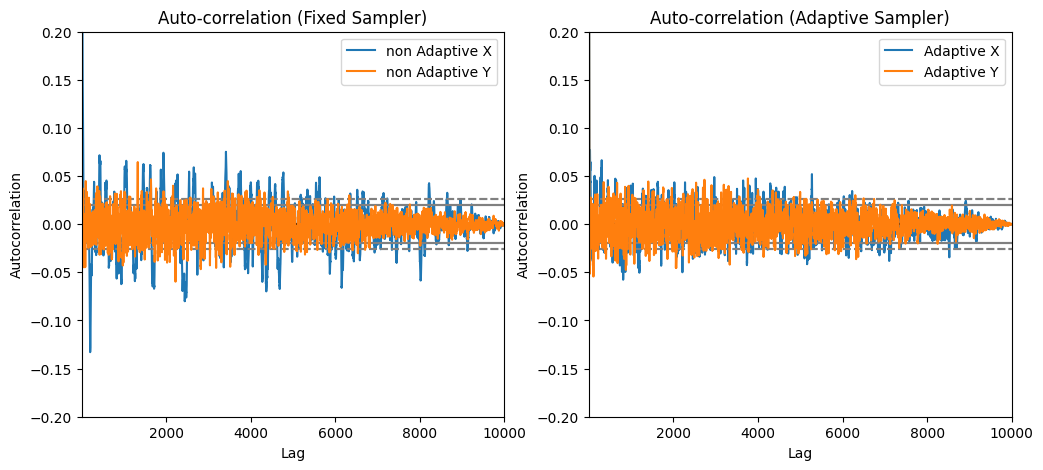

In [7]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
pd.plotting.autocorrelation_plot(samples_nonadapted[:, 0], label='non Adaptive X')
pd.plotting.autocorrelation_plot(samples_nonadapted[:, 1], label='non Adaptive Y')
plt.title("Auto-correlation (Fixed Sampler)")
plt.ylim(-0.2, 0.2)

plt.subplot(1, 2, 2)
pd.plotting.autocorrelation_plot(samples_adapted[:, 0], label='Adaptive X')
pd.plotting.autocorrelation_plot(samples_adapted[:, 1], label='Adaptive Y')
plt.title("Auto-correlation (Adaptive Sampler)")
plt.ylim(-0.2, 0.2)

plt.show()

## 1.B Question 2:

**summary:** Using the exact same algorithm define in previous question, we observed that Adaptive Metropolis-Hastings algorithm performs very well on the complex, non-linear "Banana" density, without any fine-tuning.
The samples match very well the contours of the target distribution, indicating effective exploration of the banana geometry and the acceptance rates drop faster to target value than in previous question.

In [8]:


def log_banana_distri(x_vec, B=0.4, d=5):
  '''
  Compute the logarithm banana distribution fB
  '''
  x1 = x_vec[0]
  x2 = x_vec[1]
  x_left = x_vec[2:]

  fB_distri = (-0.5*x1**2 -0.5*(x2 + B*x1**2 - B)**2 + -0.5*np.sum(x_left**2))
  return fB_distri



B = 0.4
d=5
x0_banana = np.zeros(5)
samples_adapted, acceptance_rate_adapted, history_sigmas_adapted = AdaptativeMetropolisHastings(log_banana_distri,n_iter, x0_banana, sigmas=sigmas,a=B, adaptation=True)




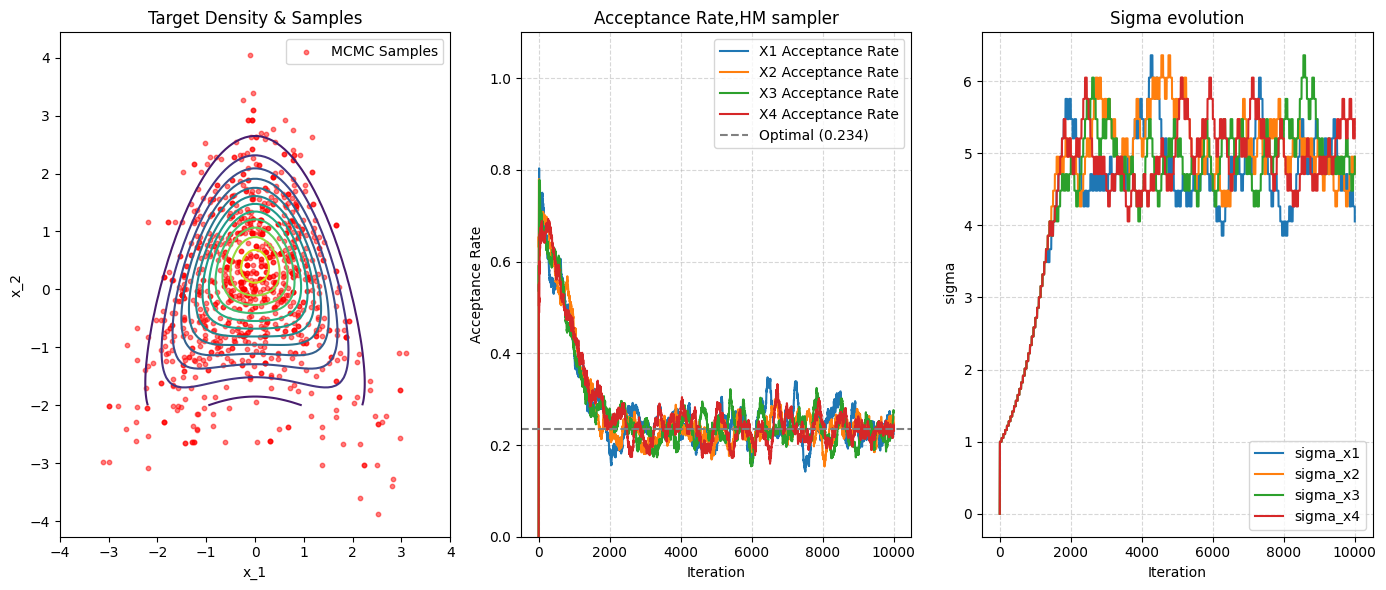

In [9]:
### Plotting
plt.figure(figsize=(14, 6))

# 1. Scatter Plot + Contour
plt.subplot(1, 3, 1)

# Create a grid for the contour plot
x_grid = np.linspace(-4, 4, 100)
y_grid = np.linspace(-2, 4, 100)
X, Y = np.meshgrid(x_grid, y_grid)
Z = np.zeros_like(X)

for i in range(X.shape[0]):
  for j in range(X.shape[1]):
    vec = np.zeros(d)
    vec[0] = X[i, j]
    vec[1] = Y[i, j]
    Z[i, j] = np.exp(log_banana_distri(vec, B=B))

# Contour
plt.contour(X, Y, Z, levels=15, cmap='viridis')
max_display = min(n_iter,1000)
plt.scatter(samples_adapted[:max_display, 0], samples_adapted[:max_display, 1], s=10, alpha=0.5, color='red', label='MCMC Samples')
plt.title(f'Target Density & Samples')
plt.xlabel('x_1')
plt.ylabel('x_2')
plt.legend()

# 2. Acceptance Rate Plot
plt.subplot(1, 3, 2)

series_x1 = pd.Series(acceptance_rate_adapted[:, 0]) # handles NaN values
series_x2 = pd.Series(acceptance_rate_adapted[:, 1])
series_x3 = pd.Series(acceptance_rate_adapted[:, 2])
series_x4 = pd.Series(acceptance_rate_adapted[:, 3])
window = max(10,int(n_iter/50))
rate_x1 = series_x1.rolling(window=window, min_periods=1).mean() # compute rate with rolling mean
rate_x2 = series_x2.rolling(window=window, min_periods=1).mean()
rate_x3 = series_x3.rolling(window=window, min_periods=1).mean()
rate_x4 = series_x4.rolling(window=window, min_periods=1).mean()

plt.plot(rate_x1, label='X1 Acceptance Rate')
plt.plot(rate_x2, label='X2 Acceptance Rate')
plt.plot(rate_x3, label='X3 Acceptance Rate')
plt.plot(rate_x4, label='X4 Acceptance Rate')

plt.title(f'Acceptance Rate,HM sampler')
plt.xlabel('Iteration')
plt.ylabel('Acceptance Rate')
plt.ylim(0, 1.1)
plt.axhline(0.234, color='gray', linestyle='--', label='Optimal (0.234)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)


# 3. Sigmas evolution
plt.subplot(1, 3, 3)

plt.plot(history_sigmas_adapted[:,0], label='sigma_x1')
plt.plot(history_sigmas_adapted[:,1], label='sigma_x2')
plt.plot(history_sigmas_adapted[:,2], label='sigma_x3')
plt.plot(history_sigmas_adapted[:,3], label='sigma_x4')

plt.title(f'Sigma evolution')
plt.xlabel('Iteration')
plt.ylabel(' sigma')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Exercice 2: Sampling from multimodal distributions

## 2.A question 1:

**summary:** We implemented the target_distribution as defined in the document. The only tricky part was the crucial need for 'logsumexp' function as the probabilities in the empty space between modes is underflowing to zero, causing numerical issues.



In [10]:
from google.colab import drive
drive.mount('/content/drive')

#!ls -al "/content/drive/MyDrive/Colab_Notebooks/MVA25-26/Computational_Statistics/TPs"
current_path = "/content/drive/MyDrive/Colab_Notebooks/MVA25-26/Computational_Statistics/TPs/"
sys.path.append(current_path)
file_path = current_path + "20means.npy"

mu = np.load(file_path)

Mounted at /content/drive


In [11]:
from scipy.special import logsumexp

w, sigma = 0.05, 0.1

def log_target_distri(x,mu,w,sigma):
  '''
  Compute the logarithm target distribution Pi

  We use logsumexp for numerical stability
  '''
  if x.ndim == 1:
    x = x[np.newaxis, :]

  # log cst prefix
  log_terms = np.log(w) - np.log(2 * np.pi * sigma**2)

  # log exp(.)
  sq_distance_mu = np.sum((x[:, np.newaxis, :] - mu[np.newaxis, :, :])**2, axis=2)  # We calculate ||x - mu_i||^2
  log_exp_terms =  -0.5*sq_distance_mu/(sigma**2)

  log_terms = log_terms + log_exp_terms
  return logsumexp(log_terms, axis=1)

def target_distri(x,mu,w,sigma):
  '''
  Compute the target distribution Pi
  '''
  return np.exp(log_target_distri(x, mu, w, sigma))


## 2.A question 2:

**summary:** We used standard Metropolis-Hastings Symmetric Random Walk (MH_SRW) algorithm, inspired from last tutorial class, then just adding the 'adaptative' section.


In [12]:



def MetropolisHastings_RW(log_target_distri, x0, n_iter, sigma_prop,mu,w,sigma,batch_size=50,adaptation=False):
  '''
  Symmetric Random Walk Metropolis-Hastings.
  Proposal: x* ~ N(x_curr, sigma_prop^2*I)
  '''
  d = len(x0)
  samples = np.zeros((n_iter, d))
  samples[0] = x0
  x_curr = x0.copy()

  if not adaptation:
    ls = np.zeros(d)
    sigmas = np.ones(d) * sigma_prop
  else:
    ls = np.zeros(d)
    sigmas = li_2sigma(ls)

  acceptance_rate_batch = np.zeros(batch_size)
  acceptance_rate = np.zeros(n_iter)

  j_th_batch = 0
  for i in range(1, n_iter):

    if i%batch_size == batch_size-1 and adaptation:
      j_th_batch += 1
      delta_j = delta_updator(j_th_batch)
      ls += delta_j*np.sign((np.nanmean(acceptance_rate_batch[:])-0.234))
      sigmas = li_2sigma(ls)

    # 1. Propose: Add Gaussian noise
    x_prop = x_curr + sigmas * np.random.randn(d)

    # 2. Compute Log Acceptance Probability
    log_pi_curr = log_target_distri(x_curr,mu,w,sigma)
    log_pi_prop = log_target_distri(x_prop,mu,w,sigma)

    # Log ratio: log(pi(x*)) - log(pi(x))
    log_alpha = log_pi_prop - log_pi_curr # (Symmetric proposal cancels out q(x|y) terms)

    # 3. Accept or Reject
    if np.log(np.random.rand()) < log_alpha:
      x_curr = x_prop
    else:
      x_curr = x_curr

    acceptance_rate_batch[i%batch_size] = np.exp(log_alpha)
    acceptance_rate[i] = np.exp(log_alpha)

    samples[i] = x_curr

  return samples, acceptance_rate




n_iter = 5000
x0 = 10*np.random.rand(2)
sigma_prop = 1

samples, acceptance_rate = MetropolisHastings_RW(log_target_distri, x0, n_iter, sigma_prop,mu,w,sigma,adaptation=False)
samples_adapted, acceptance_rate_adapted = MetropolisHastings_RW(log_target_distri, x0, n_iter, sigma_prop,mu,w,sigma,adaptation=True)



/tmp/ipython-input-2609995079.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  acceptance_rate_batch[i%batch_size] = np.exp(log_alpha)
/tmp/ipython-input-2609995079.py:47: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  acceptance_rate[i] = np.exp(log_alpha)


## 2.A question 3:

**summary:** The figures clearly show that both the classic MH_SRW sampler and the adaptative version fail to sample the distribution. The algorithms get stuck in local modes and cannot cross the empty space (especially the adaptive one which is tuning sigmas for better sampling of local modes). Thus, by setting a larger sigma, the adaptative version still underexplore the modes, while the non adaptative version explore more modes, but with extremely low acceptance rate, leading to very not efficient sampling.


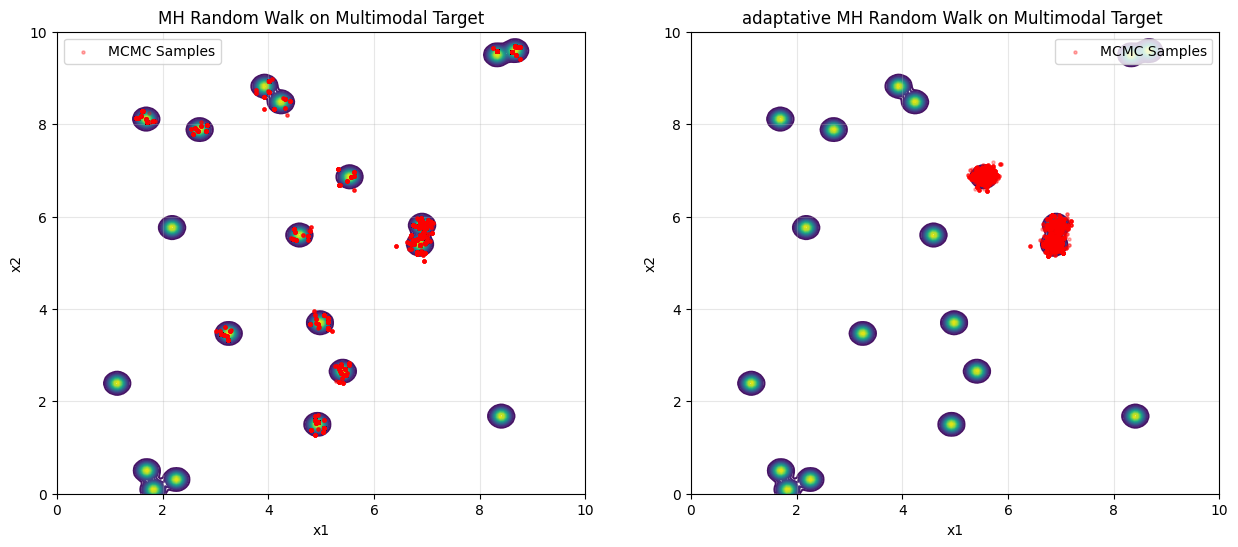

In [13]:
# Plot Contour and samples scatter
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)

# Contours
x_grid = np.linspace(0, 10, 200)
y_grid = np.linspace(0, 10, 200)
X, Y = np.meshgrid(x_grid, y_grid)
pos = np.dstack((X, Y)).reshape(-1, 2)
Z = target_distri(pos,mu,w,sigma).reshape(200, 200)
plt.contour(X, Y, Z, levels=20, cmap='viridis', zorder=1)

# Samples
plt.scatter(samples[:, 0], samples[:, 1], s=5, color='red', alpha=0.3, label='MCMC Samples', zorder=2)
plt.title(f"MH Random Walk on Multimodal Target")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel("x1")
plt.ylabel("x2")

plt.subplot(1, 2, 2)

# Contours
plt.contour(X, Y, Z, levels=20, cmap='viridis', zorder=1)

# Samples
plt.scatter(samples_adapted[:, 0], samples_adapted[:, 1], s=5, color='red', alpha=0.3, label='MCMC Samples', zorder=2)
plt.title(f"adaptative MH Random Walk on Multimodal Target ")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel("x1")
plt.ylabel("x2")

plt.show()

## 2.B question 1:

**summary:** Sampling from a distribution $\pi^{1/T1}$ with T1 >1 is easier because the power(1/T) "flattens" the distirbution, making shallower the empty space between modes, and wider the peak of the modes, enabling cheaper exploration.




## 2.B question 2:

**summary:** We implemented the Parallel Tempering algorithm with K=5 chains running at the given temperatures, and took $\tau_i=0.25*\sqrt{T_i}$.
Each chain evolves independently via a local Gaussian Random Walk. As sugested in the pseudo-code, at every iteration, we used a swapping between two randomly selected chains.

In [18]:



def MH_parallel_Tempering(log_target_func, n_iter, x0, temperatures):
  K = len(temperatures)
  d = x0.shape[1]

  chains_history = np.zeros((n_iter, K, d))
  chains_history[0] = x0
  x_curr = x0.copy()

  log_pi_curr_stack = np.zeros(K)
  for k in range(K):
    log_pi_curr_stack[k] = log_target_func(x_curr[k], mu, w, sigma)

  for it in range(1, n_iter):

    log_pi_Yn_p1 = np.zeros(K)
    for k in range(K): # MH on each chain
      Ti = temperatures[k]
      tau_i = 0.25*np.sqrt(Ti)

      # 1. Propose: Add Gaussian noise
      x_prop = x_curr[k] + tau_i*np.random.randn(d)

      # 2. Compute Log Acceptance Probability
      log_pi_curr = log_pi_curr_stack[k]
      log_pi_prop = log_target_func(x_prop, mu, w, sigma)[0]
      log_pi_Yn_p1[k] =  log_pi_prop

      # Log ratio: log(pi(x*)) - log(pi(x))
      log_alpha = (1/Ti)*(log_pi_prop - log_pi_curr) # (Symmetric proposal cancels out q(x|y) terms), power(1/T) fall down as a product with the log

      # 3. Accept or Reject
      if np.log(np.random.rand()) < log_alpha:
        x_curr[k] = x_prop
        log_pi_curr_stack[k] = log_pi_prop
      #else:
      #  x_curr = x_curr


    ## Swapping part

    # Choose uniformly (i, j) ∈ [1,K]², with i ̸= j
    indices = np.random.choice(K, 2, replace=False)
    i, j = indices[0], indices[1]

    # Compute swap acceptance probability (log(pi_i(yj)*pi_j(yi))-log(pi_i(yi)*pi_j(yj)))
    log_alpha_swap = (1.0/temperatures[i] - 1.0/temperatures[j]) * (log_pi_curr_stack[j] - log_pi_curr_stack[i])

    # Accept or reject swapping
    if np.log(np.random.rand()) < log_alpha_swap:
      x_curr[[i,j]] = x_curr[[j,i]]
      log_pi_curr_stack[[i,j]] = log_pi_curr_stack[[j,i]]


    chains_history[it] = x_curr.copy()

  return chains_history



n_iter = 6000
temperatures = [60,21.6,7.7,2.8,1]
K = len(temperatures)
x0 = np.random.randn(len(temperatures), 2)
x0 = x0*5 + 5 # init roughly in the center of the space
history = MH_parallel_Tempering(log_target_distri, n_iter, x0, temperatures)



/tmp/ipython-input-566154779.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  log_pi_curr_stack[k] = log_target_func(x_curr[k], mu, w, sigma)


## 2.B question 3:

**summary:** We observed that unlike the standard and adaptative MH_SRW samplers (which got trapped into local modes), the Parallel Tempering algorithm successfully explores all 20 modes of the distribution.

However, we noticed that some samples are actually far from the modes, lost in the empty space. Those samples are coming from high temperature chains. In fact, through the swapping step, these global discoveries are transferred down to the cold chain (T=1), allowing it to sample from the correct multimodal density without getting stuck, but also allowing outliers with a non-zero probability.

Overall, tempering algorithm successfuly sampled the multimodal distirbution, but the sampling might require post curation (and tuning of the temperatures as stressed by the document).

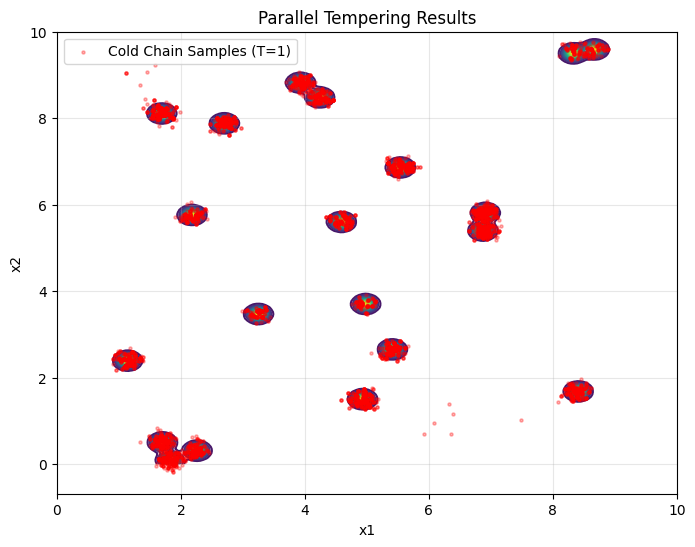

In [19]:

### Plot
plt.figure(figsize=(8, 6))

# Contour Plot
x_grid = np.linspace(0, 10, 200)
y_grid = np.linspace(0, 10, 200)
X, Y = np.meshgrid(x_grid, y_grid)
pos = np.dstack((X, Y)).reshape(-1, 2)
Z = target_distri(pos, mu, w, sigma).reshape(200, 200)
plt.contour(X, Y, Z, levels=15, cmap='viridis', zorder=1)

# Plot samples
samples_TK = history[:, -1, :]
max_display = min(n_iter,5000)
plt.scatter(samples_TK[:max_display, 0],samples_TK[:max_display, 1], s=5, color='red', alpha=0.3, label='Cold Chain Samples (T=1)', zorder=2)
plt.title(f"Parallel Tempering Results")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Exercise 3: Bayesian analysis of a one-way random effects model

## Question 1:



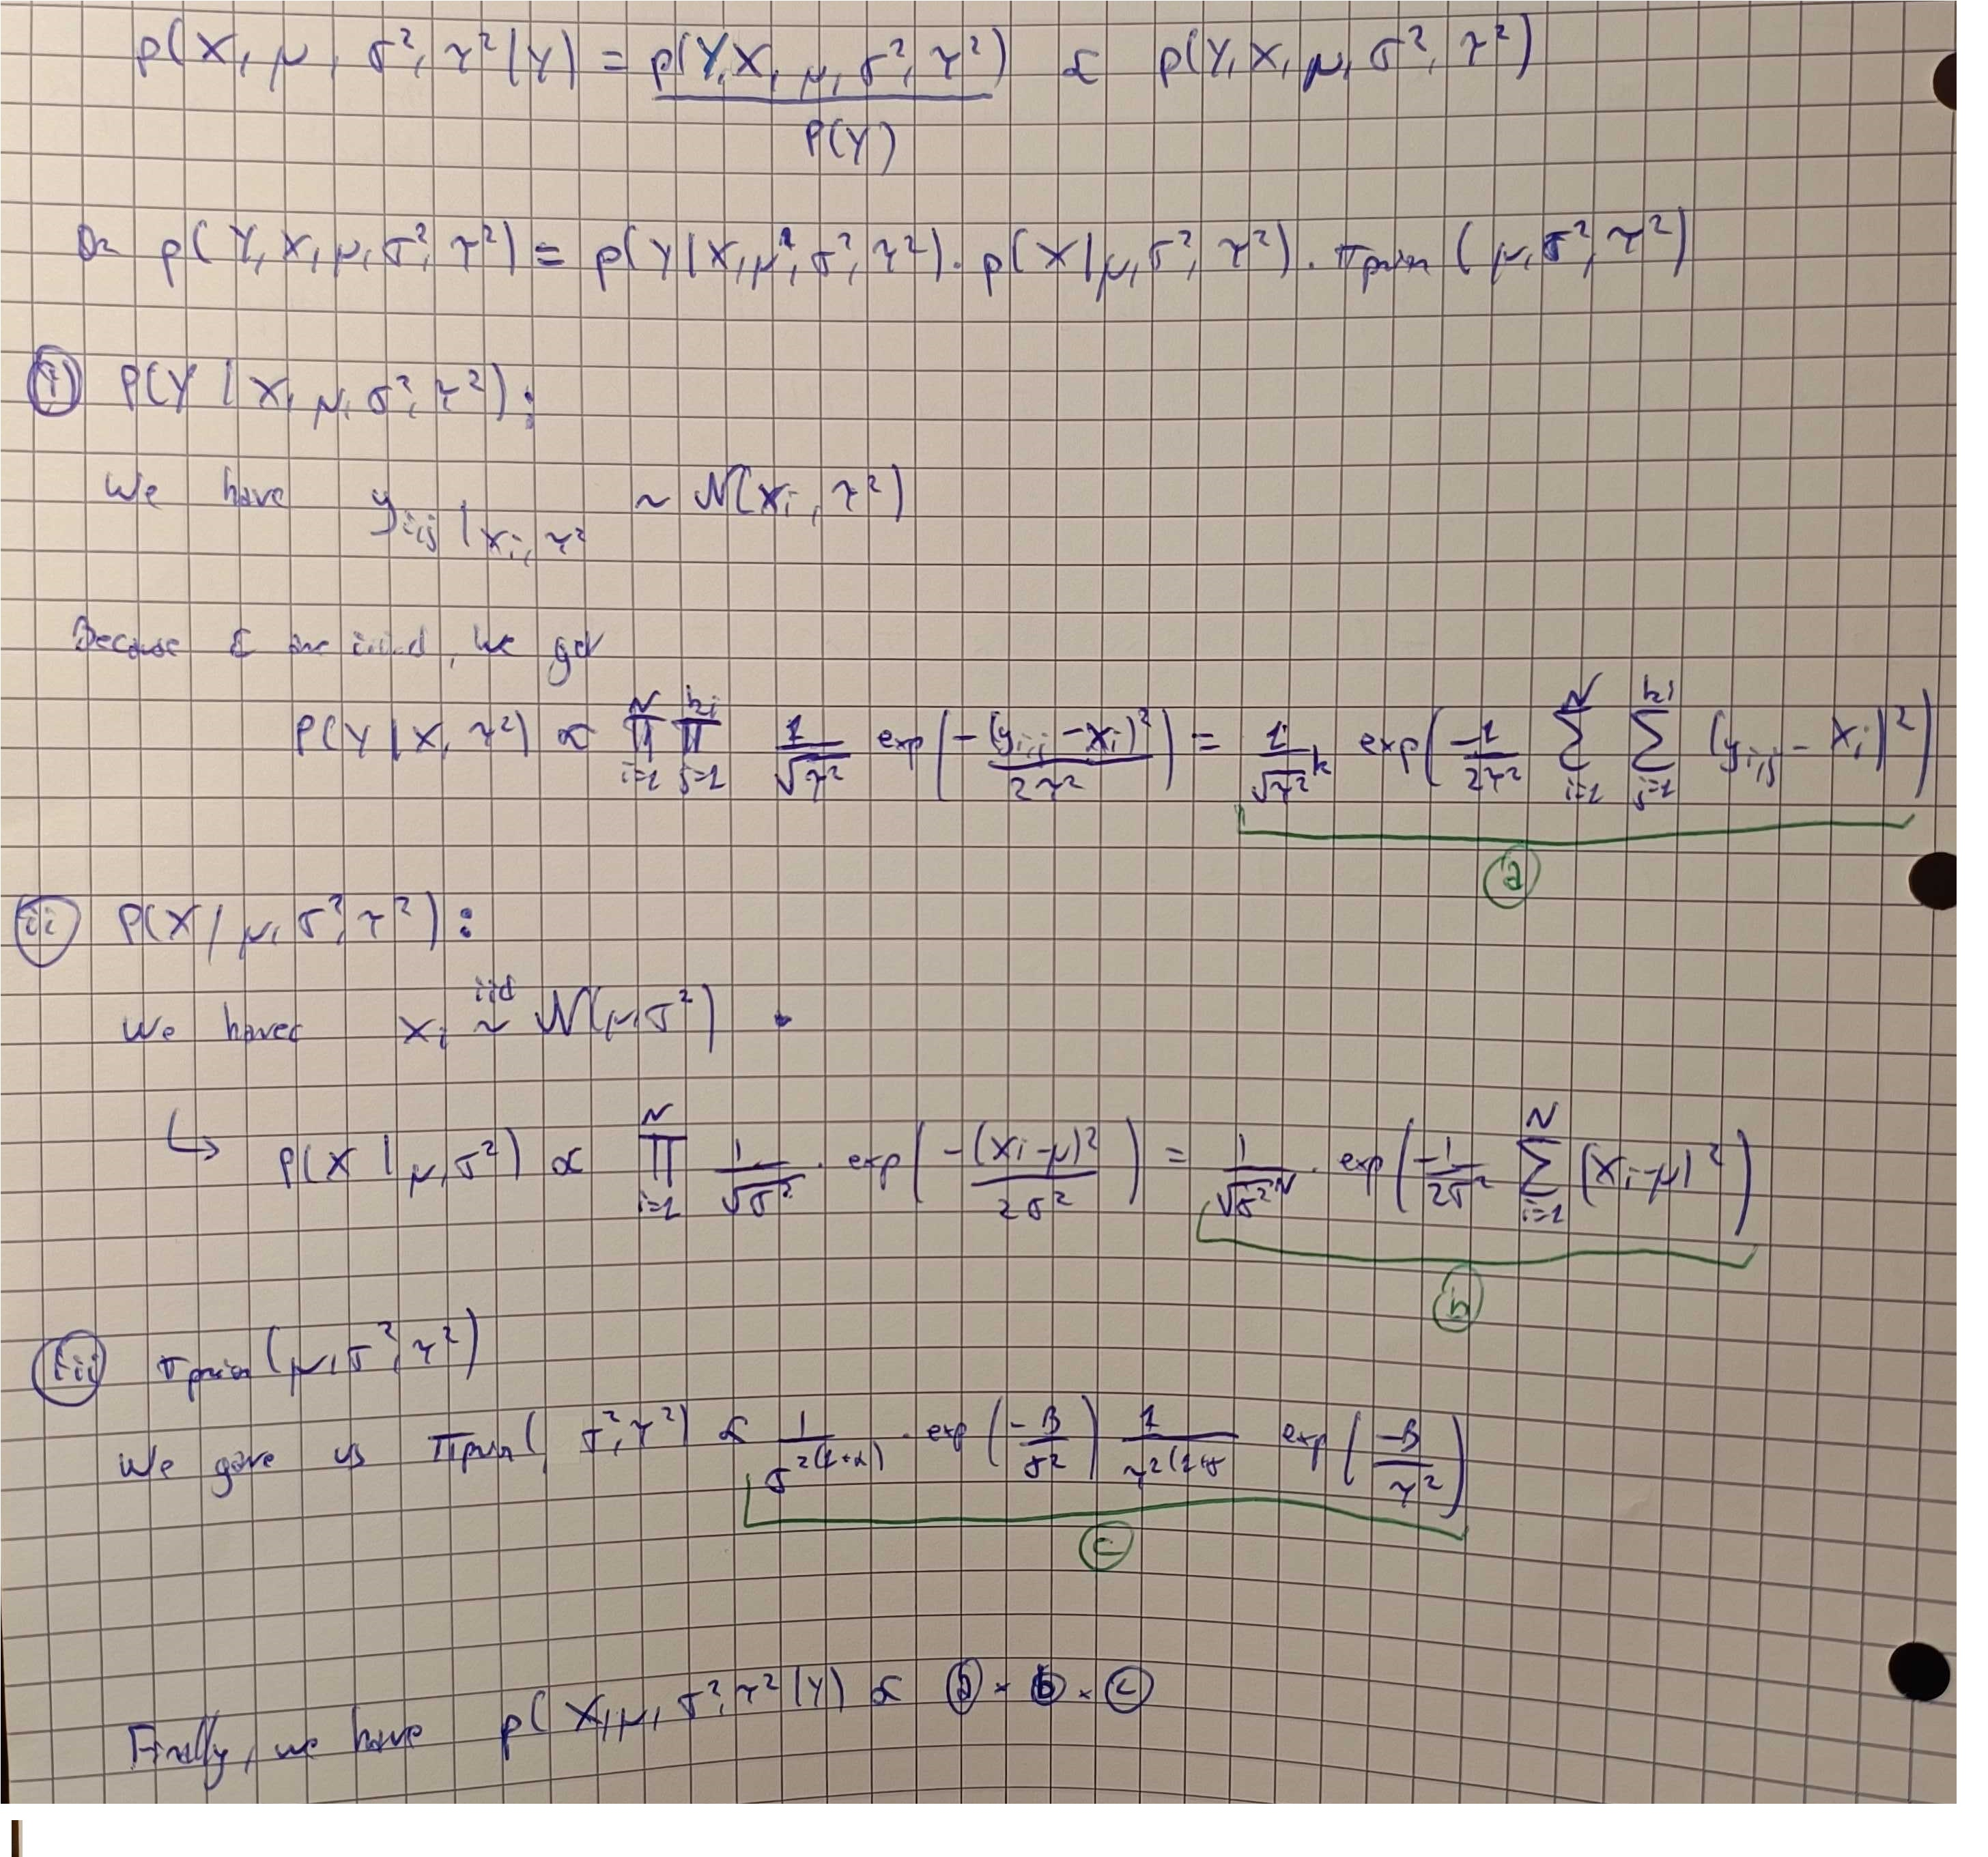